<a href="https://colab.research.google.com/github/AdrianFajardo24/Telecom-analysis/blob/main/S7%20Version-Estudiante-Project-ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
   En la tabla de **Users**, las columnas de **city** y **churn_date** son las que tiene valores nulos. La columna de city con el 11.7% y la columna de **churn_date** tiene el 88.3% de valores nulos.
  En la tabla de **usage** las columnas de **date**, **duration** y **length** son las que tienen datos nulos. La columna de **date** tiene una proporción del 0.12%, mientras que la de **duration** la tiene del 55.2% y la de **length** de 44.7%.   
- Indica qué harías: ¿imputar, eliminar, ignorar?
  La columna de **churn_date** se puede eliminar debido a la alta cantidad de valores nulos (88.3%). La columna de **city** se dejarían los nulos pues no es posible saber la ciudad de origen del usuario. La columna de **date** debido al bajo valor de nulos (0.12%) se puede ignorar, aunque lo ideal sería poder completar esa información. Para las columnas de **duration** y **length** se revisará la inforamción para imputarla o mantenerla como nula.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene sus valores de promedio y de mediana iguales, lo que indica desde el inicio que no tiene una considerable variación en sus datos.
- La columna `age` si tiene variación en sus resultados entre el promedio y la mediana, muy posiblemente a los valores fuera de rango lógico que tiene, como se muestra en el mínimo cuyo valor es -999, una edad que no puede existir.

In [ ]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`están muy relacionadas una con otra, pero los resultados muestran que la cantidad de usuarios registrados es mucho menor que la cantidad total de "ID's" disponibles, y este dato es fácil de ver en la fila de los "max", donde indica que hay 40 mil ID's disponibles y solo se han usado 14 mil.
- Las columnas `duration` y `length` se pueden var la cantidad de minutos usados y la longitud de los mensajes enviados respectivamente. Considero que no hay mucho que explicar aquí, solo tomar en cuenta la duración máxima que han tenido las llamadas (120 min) y la longitud máxima de texto en un mensaje (1490), datos que pueden ser relevantes para el análisis de los planes usados y lo que cada uno ofrece.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts())
    print(users[col].value_counts(normalize = True))

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64
Basico     2595
Premium    1405
Name: plan, dtype: int64
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


- La columna `city` muestra que la ciudad de Bogotá es la que representa el mayor porcentaje de usuarios registrados (22.8%), mientras que Monterrey es la que menos usuarios registra (11.5%). Hay registros desconocidos que no son un porcentaje representativo para el análisis (2.7%).
- La columna `plan` muestra que el plan básico es el más contratado, con un 64.8% de contratación entre los usuarios.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].value_counts())
print(usage['type'].value_counts(normalize = True))

text    22092
call    17908
Name: type, dtype: int64
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` muestra que el uso de mensajes es el mas habitual entre los usuarios, representando un 55.2%.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En la columna `age` se encontraron valores inválidos, pues muestra un mínimo de edad de -999, algo imposible.
- ¿Qué acción tomarías?
  Tomando en cuenta los datos estadísticos, sustituiría esos valores por la mediana para no alterar tanto el conteo y registros tomados.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = "coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = "coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, sí aparece la información de los años 2022 a 2024, pero muestra 40 valores del año 2026, lo cual no debería ser, debido al límite 2024 que debe tener la información registrada.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solo se muestra la información del año 2024, pero el total de la frecuencia mostrada para este año coincide con el total mostrado en la inspección inicial; de los demás años no muestra información alguna.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos):
  De acuerdo a la información mostrada, el único año fuera del rango es el 2026 (año futuro o sin transcurrir).
- ¿Qué harías con ellas?:
  En este caso, al ser muy baja la frecuencia para este año, se pueden omitir para el análisis (dejarla como nula).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print(users['city'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe tu diagnostico de nulos en `duration` y `length`

En base a los resultados obtenidos, los valores son MAR, porque se ve que ambos valores tienen dependencia de la columan `type`, pues solo las llamadas tienen duración de tiempo y los mensajes no (por eso resulta en 0); por el contrario los mensajes son los que tienen longitud debido al conteo de los carcteres utilizados, algo que no sucede en las llamadas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how = 'left')
user_profile.head(5)
#user_profile['cant_mensajes'].describe()
#user_profile['cant_llamadas'].describe()
#user_profile['cant_minutos_llamada'].describe()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize = True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

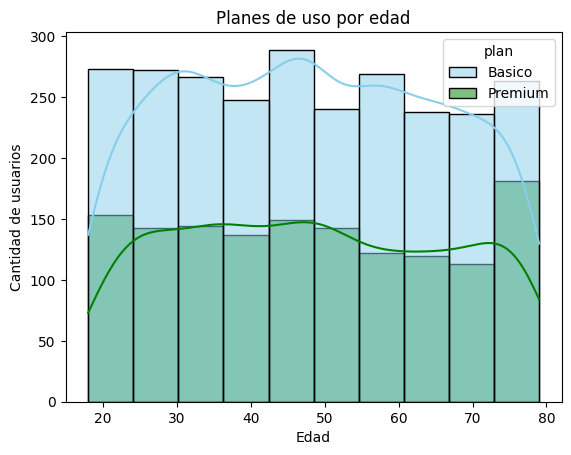

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, bins = 10, palette = ['skyblue', 'green'], x= 'age', hue='plan', kde = True)
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.title("Planes de uso por edad")
plt.show()

💡Insights:
- Distribución: la proporción entre los planes y las edades de los usuarios se mantiene muy parecida entre uno y otro, sin embargo, se puede apreciar una diferencia notable con los rangos de edad mas grandes (desde los 73 hasta los 79 años) pues la mayoría de personas dentro de este rango de edad usa el plan premium, mientras que con todas las demás edades hay una proporción de un 65% (básico) vs 35% (premium), tal como lo arroja la distribución porcentual de estos dos planes de pago.

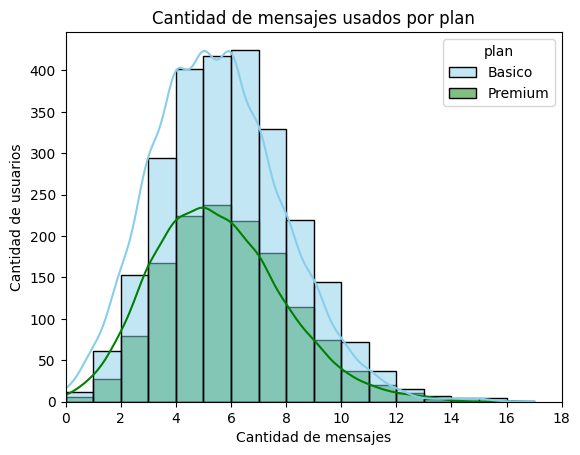

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, bins = 17, palette = ['skyblue', 'green'], x= 'cant_mensajes', hue='plan', kde = True)
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de mensajes usados por plan")
plt.xlim(0, 18)
plt.show()

💡Insights:
- La distribución de esta gráfica es sesgada a la derecha, lo que indica que la cantidad de mensajes usados por cada usuario es muy poca, la mayoría realiza entre 4 a 7 mensajes por plan. Cabe mencionar que se sigue apreciando que la mayoría de usuarios (aproximadamente el 65%) usa el plan básico mientras que el resto (aproximadamente el 35%) usa el plan premium, proporción vista desde la gráfica anterior.

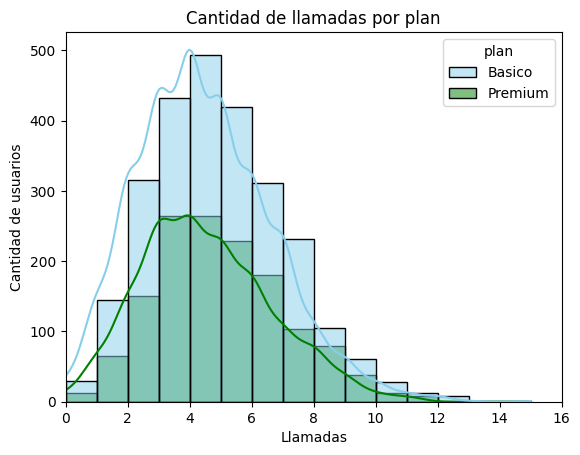

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, bins = 15, palette = ['skyblue', 'green'], x= 'cant_llamadas', hue='plan', kde = True)
plt.xlabel("Llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de llamadas por plan")
plt.xlim(0, 16)
plt.show()

💡Insights:
- Distribución: al igual que la gráfica anterior, estos datos están sesgados hacia la derecha lo que significa que la mayoría de los usuarios hacen pocas llamadas con su respectivo plan de uso, la mayoría de datos caen entre 3 a 6 llamadas hechas por usuario. Prevalece la relación 65%-35% entre el plan básico vs el plan premium respectivamente.

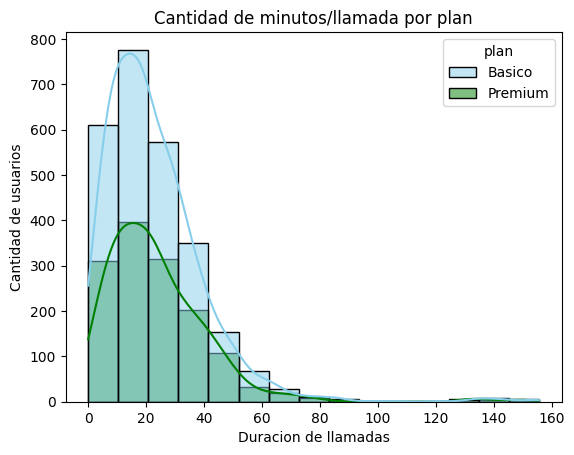

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, bins = 15, palette = ['skyblue', 'green'], x= 'cant_minutos_llamada', hue='plan', kde = True)
plt.xlabel("Duracion de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Cantidad de minutos/llamada por plan")
plt.show()

💡Insights:
- Distribución: Se aprecia un notable sesgo a la derecha, más pronunciado que en las dos gráficas anteriores, sin embargo, aquí se pueden ver un conjunto muy pequeño de datos que se apartan bastante del conjunto principal y esto indica que hay una muy pequeña cantidad de usuarios que hacen llamadas de más de 120 minutos y hasta 155 minutos como duración máxima. Se conserva la proporción que se ha venido viendo entre los planes básico y premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráficos, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

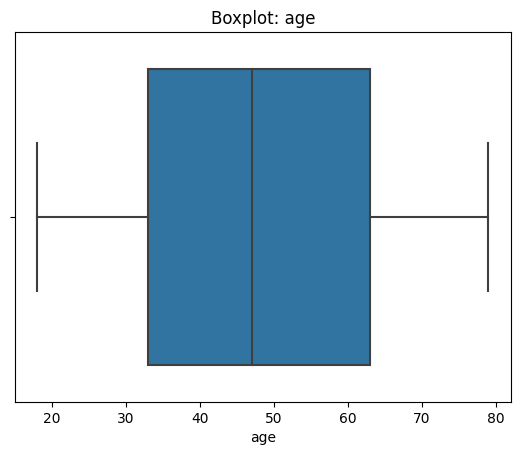

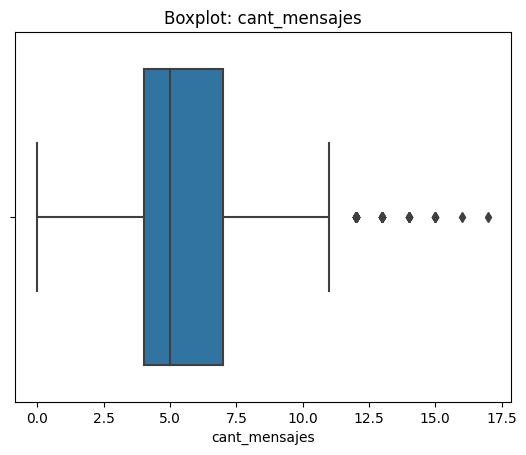

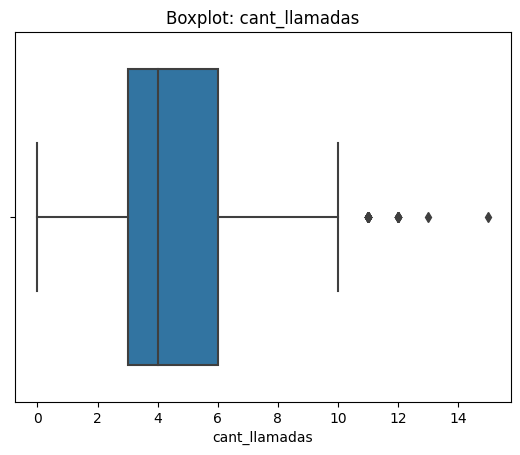

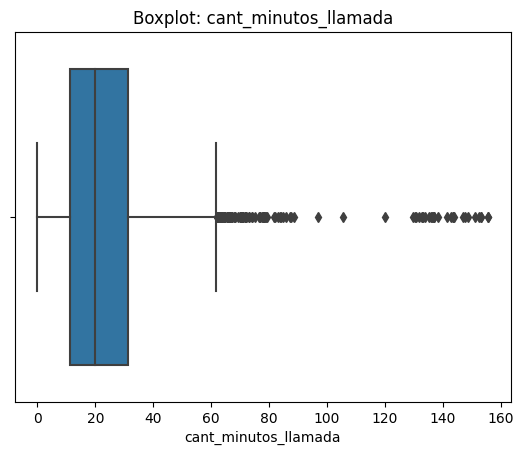

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x = user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights:
- Age: No presenta outliers
- cant_mensajes: Si presenta outliers
- cant_llamadas: Si presenta outliers
- cant_minutos_llamada: Si presenta outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    print(col, "IQR: ", IQR)
    upper=Q3+1.5*IQR
    print("Valor superior: ", upper)
    lower=Q1-1.5*IQR
    print("Valor inferior: ", lower)
    display(user_profile[(user_profile[col]>upper) | (user_profile[col]<lower)])


cant_mensajes IQR:  3.0
Valor superior:  11.5
Valor inferior:  -0.5


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
315,10315,Carlos,Lopez,30.0,MTY,2022-03-28 06:04:03.060765192,Basico,NaN,13.0,3.0,12.36
347,10347,Carlos,Garcia,77.0,Cali,2022-04-06 00:21:36.324081021,Basico,NaN,13.0,3.0,21.40
356,10356,Mateo,Garcia,42.0,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN,12.0,5.0,59.48
384,10384,Sofia,Ramirez,35.0,CDMX,2022-04-16 03:30:39.159789948,Premium,NaN,12.0,3.0,13.05
456,10456,Mateo,Ramirez,47.0,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18",12.0,1.0,2.24
539,10539,Sofia,Ramirez,77.0,Cali,2022-05-28 14:06:55.903975994,Basico,NaN,14.0,5.0,8.66
591,10591,Ana,Gomez,25.0,NaN,2022-06-11 19:50:27.456864216,Basico,NaN,12.0,2.0,16.52
670,10670,Carlos,Torres,47.0,Bogotá,2022-07-03 11:00:02.700675170,Basico,NaN,12.0,3.0,19.13
903,10903,Carlos,Lopez,63.0,CDMX,2022-09-05 06:11:36.774193548,Premium,"1,72938E+18",12.0,3.0,8.89
908,10908,Mariana,Lopez,56.0,MTY,2022-09-06 15:03:06.346586648,Basico,NaN,14.0,3.0,12.50


cant_llamadas IQR:  3.0
Valor superior:  10.5
Valor inferior:  -1.5


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
116,10116,Ana,Garcia,52.0,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN,3.0,11.0,44.32
417,10417,Luis,Garcia,70.0,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN,4.0,12.0,26.42
777,10777,Sofia,Lopez,65.0,Cali,2022-08-01 18:09:59.549887472,Basico,NaN,4.0,12.0,55.28
778,10778,Mateo,Lopez,77.0,NaN,2022-08-02 00:44:17.464366092,Basico,NaN,8.0,11.0,32.13
862,10862,Luis,Ramirez,23.0,Bogotá,2022-08-25 00:45:22.280570144,Basico,NaN,4.0,15.0,78.11
1013,11013,Mateo,Lopez,65.0,CDMX,2022-10-05 09:04:27.366841712,Basico,NaN,4.0,11.0,60.83
1564,11564,Carlos,Lopez,41.0,CDMX,2023-03-05 06:02:58.244561144,Basico,NaN,8.0,11.0,30.17
1614,11614,Mateo,Garcia,73.0,Bogotá,2023-03-18 22:37:53.968492128,Basico,NaN,5.0,11.0,41.80
1912,11912,Mariana,Garcia,48.0,Medellín,2023-06-08 12:58:52.483120784,Premium,NaN,2.0,11.0,65.71
2013,12013,Mateo,Lopez,48.0,GDL,2023-07-06 04:43:01.845461368,Basico,NaN,2.0,12.0,65.55


cant_minutos_llamada IQR:  20.295
Valor superior:  61.8575
Valor inferior:  -19.322500000000005


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
27,10027,Ana,Gomez,28.0,MTY,2022-01-08 09:26:03.690922730,Premium,NaN,8.0,7.0,84.77
85,10085,Carlos,Ramirez,65.0,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6.0,5.0,152.36
93,10093,Ana,Torres,67.0,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN,2.0,7.0,71.57
189,10189,Mariana,Torres,63.0,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,9.0,4.0,155.42
198,10198,Sofia,Gomez,58.0,Medellín,2022-02-24 05:11:07.066766692,Basico,"1,73033E+18",8.0,9.0,78.77
...,...,...,...,...,...,...,...,...,...,...,...
3920,13920,Mariana,Lopez,48.0,Bogotá,2024-12-09 08:50:24.756189056,Premium,NaN,4.0,5.0,132.72
3927,13927,Mariana,Lopez,18.0,GDL,2024-12-11 06:50:30.157539392,Basico,"1,72549E+18",8.0,4.0,135.96
3945,13945,Luis,Ramirez,30.0,Bogotá,2024-12-16 05:07:52.618154544,Basico,NaN,7.0,3.0,133.97
3953,13953,Mateo,Gomez,58.0,GDL,2024-12-18 09:42:15.933983504,Basico,NaN,0.0,7.0,155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?: Mantener, porque son valores que sí se pueden dar en determinado momento, representan un comportamiento real.
- cant_llamadas: mantener o no outliers, porqué?: Así como con los mensajes hay que mantenerlos, porque también son valores que representan un comportamiento real.
- cant_minutos_llamada: mantener o no outliers, porqué?: No los mantendría pues distorsionan el análisis al ser datos muy alejados del valor superior (upper) obtenido del análisis IQR, además de que interesa el enfoque en el comportamiento típico.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), "Bajo uso",
        np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), "Uso medio", "Alto uso"
        )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30), "Joven",
        np.where((user_profile['age'] < 60), "Adulto", "Adulto Mayor")
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

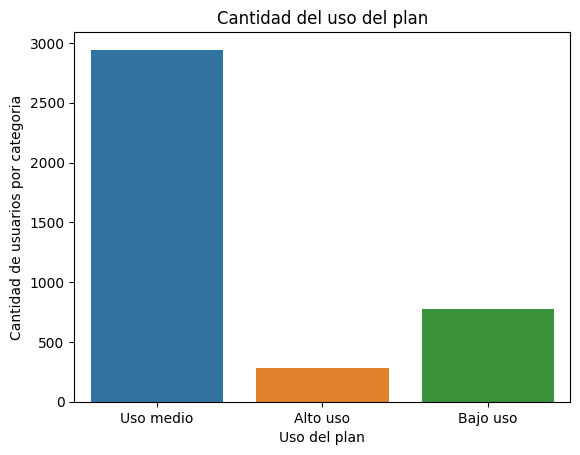

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data = user_profile, x='grupo_uso')
plt.title("Cantidad del uso del plan")
plt.xlabel("Uso del plan")
plt.ylabel("Cantidad de usuarios por categoria")
plt.show()

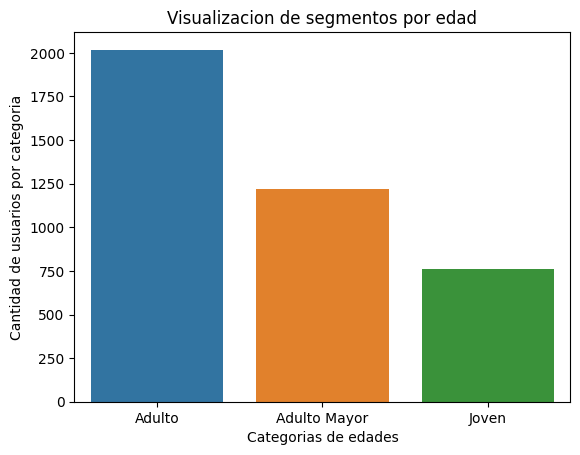

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x='grupo_edad')
plt.title("Visualizacion de segmentos por edad")
plt.xlabel("Categorias de edades")
plt.ylabel("Cantidad de usuarios por categoria")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

- Durante el análisis inicial, al explorar el contenido de cada tabla, se encontró que había datos no ingresados de determinadas categorías, aunque la mayoría de las columnas eran muy consistentes con la cantidad de información, algunas no cumplían con eso:

  1. En la tabla `Usage` faltaban el 0.12% de los datos en la fila `date`, mientras que en las filas `duration` y `length` se ven faltantes el 55.2% y el 44.7% de los datos respectivamente, sin embargo mas adelante se pudo descubrir que esa proporción se debía a las características propias del modo de contabilizar cada tipo de dato pues las llamadas usan tiempo mientras que los mensajes usan longitud de texto.
  2. En la tabla `Users` solo dos columnas mostraban datos faltantes, `city` y `churn_date`; para `city` esta proporción fue del 11.7%, un porcentaje no representativo y pudiendo eliminarlos del análisis final. Por otro lado la columna `churn_date` no se tomó para analizar pues tiene un porcentaje de 88.3% de datos faltantes.


-  Al segmentar a los clientes se dividieron por *edad* y *nivel de uso*, arrojando resultados bastante claros: la mayor cantidad de usuarios son personas adultas, con edades de más de 30 años pero menores que 60; le siguen los adultos mayores (más de 60 años) y como grupo menos numeroso el de jóvenes (menores de 30 años). Para el *nivel de uso* se tiene que el uso medio del servicio es el más utilizado, seguido por el de bajo uso y con la menor cantidad de usuarios está el alto uso del servicio.

  Ambos resultados muestran una clara distinción en sus respecctivas gráficas permitiendo distinguir a simple vista la proporción que da cada uno de los segmentos analizados.

  La relación existente que se puede deducir para ambos segmentos es que los usuarios adultos son los que consumen en mayor medida el plan de uso medio pues son el grupo economicamente activo, lo que les permite consumir este tipo de servicio por necesidades del diario.

- Los segmentos mas valiosos para ConnectaTel pudieran ser: edades, nivel de uso, cantidad de llamadas y mensajes, tipo de plan y ciudad. Todos estos porque dan información valiosa sobre los consumos de cada plan, el sector poblacional al que se pueden enfocar más y en qué ciudad conviene invertir más o dar más promociones de acuerdo al tipo de plan más utilizado.

- De los outliers encontrados el mas representativo es el que corresponde a la columna de `cant_min_llamada` porque sus datos de uso extremo revelan un sector muy raro de usuarios que emplean más de 120 minutos en una llamada, llegando como registro máximo a 160 minutos. Esto supone casos muy aislados que si bien llaman la atención, no afectan al negocio en terminos de perdidas o ganancias, a menos que se quisiera implementar alguna promoción o descuento a aquellos usuarios que hagan llamadas de más de 100 minutos por ejemplo. Los otros dos outliers encontrados son para las columnas `cant_mensajes` y `cant_llamadas`, los cuales muestran un aumento en la cantidad de mensajes y llamadas hechas por los usuarios, que no es tan aislado como en el caso anterior, pero si podría ayudar como estadística si se emplean promociones que hagan referencia a un mayor uso de estos servicios.

- Mis recomendaciones serían: campaña de marketing y promociones para los usuarios catalogados como adultos para una mayor retención o incremento de contrataciones en el plan de uso medio, pues son estos dos factores los que tienen los valores mas grandes en las gráficas además de considerar las ciudades donde estas promociones representarían una oportunidad de incremento de clientes. También se podrían generar promociones más exclusivas para aquellos usuarios de alto consumo o para adultos mayores, pues al tener necesidades diferentes se pueden cambiar los planes para este sector de usuarios. Para poder dar mejores recomendaciones, la información de costos de cada plan, su vigencia y demás servicios ofrecidos (como datos móviles, redes sociales incluidas, servicios de streaming incluidos, etc.) ayudaría mucho para complementar la información y dar más opciones a la compañía ConnectaTel para la modificaión o creación de planes de servicio.  

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la tabla *Usage* faltaban el 0.12% de los datos en la columna `date`.
- En las columnas `duration` y `length` de la tabla *Usage* se ven faltantes el 55.2% y el 44.7% de los datos respectivamente.
- En la tabla *Users* la columna `city` tiene una proporción del 11.7% en sus datos faltantes, algo no representativo para el análisis.
- En la tabla *Users* la columna `churn_date` no se tomó para analizar, tiene un porcentaje de 88.3% de datos faltantes.


🔍 **Segmentos por Edad**
- La mayor cantidad de usuarios son personas adultas, con edades de entre 30 y 60 años (2 mil usuarios).
- El segundo grupo mas numeroso en consumo son los adultos mayores de más de 60 años (1250 usuarios).
- El grupo con menos consumo son los jóvenes, con edades menores a 30 años (750 usuarios).


📊 **Segmentos por Nivel de Uso**
- El nivel de uso medio es el más utilizado, con csi 3 mil usuarios.
- El nivel de uso bajo es el segundo más utilizado, con unos 750 usuarios.
- El nivel de uso alto es el que tiene la menor cantidad de usuarios con alrededor de 400 usuarios.


➡️ Esto sugiere que los usuarios adultos son los que consumen mayoritariamente el plan de uso medio, ya que son el grupo económicamente activo, lo que les permite consumir continuamente el servicio por sus necesidades diarias.


💡 **Recomendaciones**
- Campaña de marketing y promociones para los usuarios adultos.
- Revisar las ciudades donde éstas promociones serían una oportunidad de incremento de clientes.
- Generar promociones exclusivas para usuarios de alto consumo o para adultos mayores.
- Complementar la información con los costos de cada plan, su vigencia y servicios adicionales para ampliar las recomendaciones a la compañía.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`